In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, accuracy_score
from scipy import stats
from statsmodels.stats.weightstats import ztest as ztest_std 

In [12]:
np.random.seed(10)
N = 150
3
AQI = np.random.randint(50, 300, N)             
Temperature = np.random.normal(32, 5, N)        
Humidity = np.random.normal(55, 10, N)          

AsthmaCases = 0.2 * AQI + 0.5 * Temperature - 0.3 * Humidity + np.random.normal(0, 10, N)
AsthmaCases = np.clip(AsthmaCases, 0, None)

df = pd.DataFrame({
    'AQI': AQI,
    'Temperature': Temperature,
    'Humidietytyyt;i7ty': Humidity,
    'AsthmaCases': AsthmaCases
})

print("---- Dataset Preview ----")
print(df.head(), "\n")

---- Dataset Preview ----
   AQI  Temperature   Humidity  AsthmaCases
0   59    37.624034  61.204354    17.798371
1  175    45.349365  51.243638    47.568635
2  278    38.665498  57.775631    59.077601
3   65    27.161789  58.665038    24.344666
4  114    30.742803  51.263701    17.384320 



In [3]:
X = df[['AQI', 'Temperature', 'Humidity']]
X = sm.add_constant(X)
y = df['AsthmaCases']

model = sm.OLS(y, X).fit()
print("---- OLS Regression Summary ----")
print(model.summary())

---- OLS Regression Summary ----
                            OLS Regression Results                            
Dep. Variable:            AsthmaCases   R-squared:                       0.710
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     119.4
Date:                Tue, 11 Nov 2025   Prob (F-statistic):           4.15e-39
Time:                        10:06:34   Log-Likelihood:                -550.47
No. Observations:                 150   AIC:                             1109.
Df Residuals:                     146   BIC:                             1121.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          10

t_stat = model.tvalues['AQI']
p_val = model.pvalues['AQI']
print("\n---- Regression Coefficient t-test for AQI ----")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.5f}")
if p_val < 0.05:
    print("Result: Reject H0 → AQI significantly affects asthma cases.")
else:
    print("Result: Fail to reject H0 → AQI not significant.")


In [5]:
threshold_aqi = np.median(df['AQI'])
low_aqi_cases = df[df['AQI'] < threshold_aqi]['AsthmaCases']
high_aqi_cases = df[df['AQI'] >= threshold_aqi]['AsthmaCases']

t_stat2, p_val2 = stats.ttest_ind(low_aqi_cases, high_aqi_cases, equal_var=False)  # Welch's t-test
print("\n---- Independent Samples T-Test (Low vs High AQI groups) ----")
print(f"T-statistic: {t_stat2:.3f}, P-value: {p_val2:.5f}")
if p_val2 < 0.05:
    print("Result: Significant difference between low and high AQI asthma cases.")
else:
    print("Result: No significant difference between groups.")


---- Independent Samples T-Test (Low vs High AQI groups) ----
T-statistic: -10.897, P-value: 0.00000
Result: Significant difference between low and high AQI asthma cases.


In [6]:
one_samp_t, one_samp_p = stats.ttest_1samp(df['AQI'], popmean=150)
print("\n---- One-sample T-Test for AQI Mean (vs 150) ----")
print(f"T-statistic: {one_samp_t:.3f}, P-value: {one_samp_p:.5f}")
if one_samp_p < 0.05:
    print("Result: Reject H0 → Average AQI differs significantly from 150 (t-test).")
else:
    print("Result: Fail to reject H0 → Average AQI not significantly different from 150 (t-test).")


---- One-sample T-Test for AQI Mean (vs 150) ----
T-statistic: 2.910, P-value: 0.00417
Result: Reject H0 → Average AQI differs significantly from 150 (t-test).


In [7]:
sample_mean = np.mean(df['AQI'])
pop_mean = 150
std_dev = np.std(df['AQI'], ddof=1)  # sample std
z_stat = (sample_mean - pop_mean) / (std_dev / np.sqrt(N))
p_val_z = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print("\n---- Z-Test for AQI Mean (approx / large-sample) ----")
print(f"Sample mean: {sample_mean:.3f}, Std (sample): {std_dev:.3f}")
print(f"Z-statistic: {z_stat:.3f}, P-value: {p_val_z:.5f}")
if p_val_z < 0.05:
    print("Result: Reject H0 → Average AQI differs significantly from 150 (z-test).")
else:
    print("Result: Fail to reject H0 → Average AQI not significantly different from 150 (z-test).")


---- Z-Test for AQI Mean (approx / large-sample) ----
Sample mean: 167.493, Std (sample): 73.631
Z-statistic: 2.910, P-value: 0.00362
Result: Reject H0 → Average AQI differs significantly from 150 (z-test).


In [8]:
df['AQI_Category'] = np.where(df['AQI'] < threshold_aqi, 'LowAQI', 'HighAQI')
threshold_asthma = np.median(df['AsthmaCases'])
df['Asthma_Risk'] = np.where(df['AsthmaCases'] < threshold_asthma, 'LowRisk', 'HighRisk')

contingency_table = pd.crosstab(df['AQI_Category'], df['Asthma_Risk'])
chi2, chi_p, dof, expected = stats.chi2_contingency(contingency_table)

print("\n---- Chi-Square Test of Independence ----")
print("Contingency Table:")
print(contingency_table)
print(f"\nChi2 statistic: {chi2:.3f}, p-value: {chi_p:.5f}, dof: {dof}")
print("Expected frequencies:")
print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))

if chi_p < 0.05:
    print("Result: Reject H0 → AQI category and Asthma risk are dependent (association exists).")
else:
    print("Result: Fail to reject H0 → AQI category and Asthma risk appear independent.")



---- Chi-Square Test of Independence ----
Contingency Table:
Asthma_Risk   HighRisk  LowRisk
AQI_Category                   
HighAQI             61       14
LowAQI              14       61

Chi2 statistic: 56.427, p-value: 0.00000, dof: 1
Expected frequencies:
Asthma_Risk   HighRisk  LowRisk
AQI_Category                   
HighAQI           37.5     37.5
LowAQI            37.5     37.5
Result: Reject H0 → AQI category and Asthma risk are dependent (association exists).


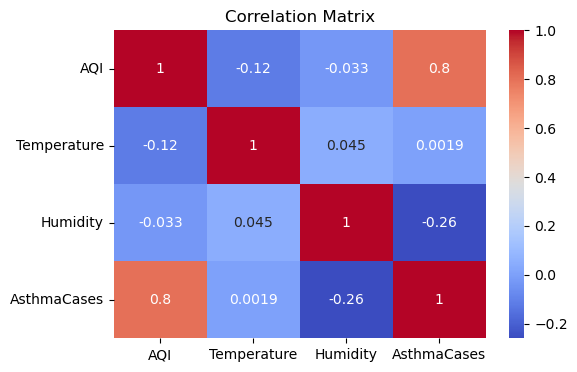

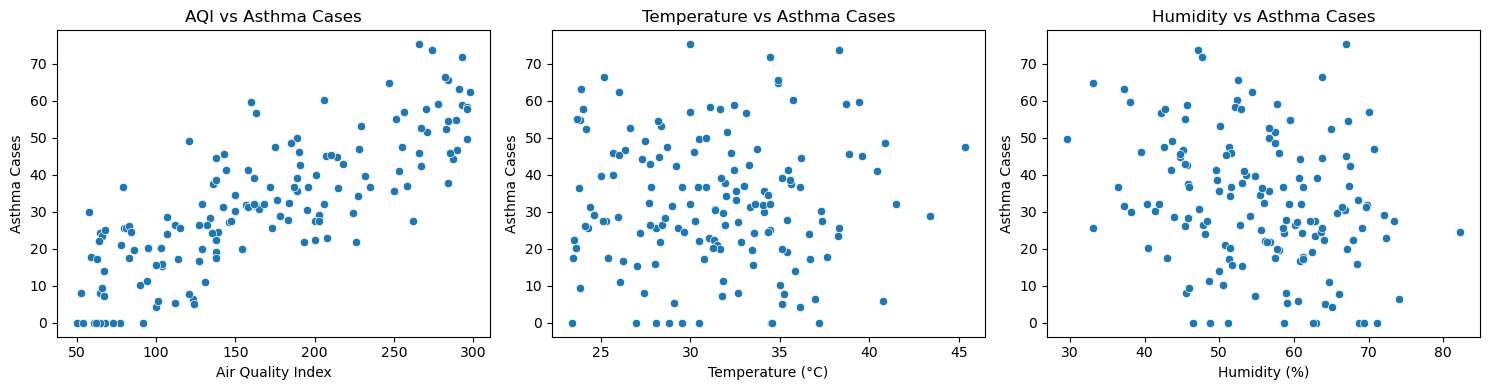

In [9]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[['AQI', 'Temperature', 'Humidity', 'AsthmaCases']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Scatter plots
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
sns.scatterplot(x='AQI', y='AsthmaCases', data=df)
plt.title('AQI vs Asthma Cases')
plt.xlabel('Air Quality Index')
plt.ylabel('Asthma Cases')

plt.subplot(1, 3, 2)
sns.scatterplot(x='Temperature', y='AsthmaCases', data=df)
plt.title('Temperature vs Asthma Cases')
plt.xlabel('Temperature (°C)')
plt.ylabel('Asthma Cases')

plt.subplot(1, 3, 3)
sns.scatterplot(x='Humidity', y='AsthmaCases', data=df)
plt.title('Humidity vs Asthma Cases')
plt.xlabel('Humidity (%)')
plt.ylabel('Asthma Cases')

plt.tight_layout()
plt.show()

In [10]:
stations = 10
A = np.zeros((stations, stations))
for i in range(stations):
    for j in range(stations):
        if abs(i - j) <= 2 and i != j:
            A[i, j] = 1

print("\n---- Adjacency Matrix ----")
print(A)

print("\nNetwork Connections:")
for i in range(stations):
    connected = [f"Station {j+1}" for j in range(stations) if A[i, j] == 1]
    print(f"Station {i+1} is connected to {', '.join(connected)}")


---- Adjacency Matrix ----
[[0. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 1. 1. 0. 0. 0. 0. 0. 0.]
 [1. 1. 0. 1. 1. 0. 0. 0. 0. 0.]
 [0. 1. 1. 0. 1. 1. 0. 0. 0. 0.]
 [0. 0. 1. 1. 0. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 1. 1. 0. 1. 1. 0.]
 [0. 0. 0. 0. 0. 1. 1. 0. 1. 1.]
 [0. 0. 0. 0. 0. 0. 1. 1. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 0.]]

Network Connections:
Station 1 is connected to Station 2, Station 3
Station 2 is connected to Station 1, Station 3, Station 4
Station 3 is connected to Station 1, Station 2, Station 4, Station 5
Station 4 is connected to Station 2, Station 3, Station 5, Station 6
Station 5 is connected to Station 3, Station 4, Station 6, Station 7
Station 6 is connected to Station 4, Station 5, Station 7, Station 8
Station 7 is connected to Station 5, Station 6, Station 8, Station 9
Station 8 is connected to Station 6, Station 7, Station 9, Station 10
Station 9 is connected to Station 7, Station 8, Station 10
Station 10 is connected to Station 8, St

In [11]:
threshold = np.median(y)
df['Predicted'] = model.predict(X)
df['ActualClass'] = np.where(df['AsthmaCases'] >= threshold, 1, 0)
df['PredClass'] = np.where(df['Predicted'] >= threshold, 1, 0)

cm = confusion_matrix(df['ActualClass'], df['PredClass'])
acc = accuracy_score(df['ActualClass'], df['PredClass'])

print("\n---- Confusion Matrix ----")
print(cm)
print(f"Model Accuracy: {acc * 100:.2f}%")


---- Confusion Matrix ----
[[63 12]
 [11 64]]
Model Accuracy: 84.67%
